# Analysis of risk of developing atherosclerotic disease — With more data

## Scientific framework
**References**: ADA Standards of Care 2024 • Goff et al., Circulation 2014 (PCE) • NCEP ATP-III • IFCC Guidelines

> **Objective**: Go beyond static diagnostic cut-offs and model cardiovascular risk as a biological continuum using NHANES 2017-2018 data.

---


### 1. Imports and configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

### 2. Pre-analytical standardisation notes

Before loading data, it is essential to document the pre-analytical and standardisation constraints that affect the reliability of the biomarkers used in this analysis.

#### HbA1c — NGSP/DCCT Standardisation

- HbA1c values in NHANES are measured with **NGSP-certified** methods, traceable to the **DCCT reference method**.
- This ensures comparability with the ADA diagnostic thresholds ($\ge 6.5\%$).
  - *Limitation*: Haemoglobin variants (HbS, HbC, HbE) and G6PD deficiency can **falsely alter** A1C values independent of actual glycaemia — a source of inter-individual bioinformatic variability.

#### Fasting Plasma Glucose (FPG) — Pre-analytical glycolysis inhibition

- NHANES collects fasting blood in tubes containing **Sodium Fluoride (NaF)** + potassium oxalate, which inhibits the enolase enzyme and blocks *in-vitro* glycolysis.
- Without NaF, glucose degrades $\sim 5–7$ mg/dL/hour at room temperature, causing **false hypoglycaemia**.
  - *Implication for the model*: a single FPG measurement carries intra-individual variability of $\pm 5–10$ mg/dL due to stress, infection, or physical activity. **This is why HbA1c (2–3 month mean) is preferred over FPG as a stability marker.**


### 3. Multi-cycle NHANES configuration

NHANES runs in 2-year cycles. Each cycle uses a different file suffix:

| Cycle | Suffix | Folder |
|---|---|---|
| 2011–2012 | `_G` | `data/2011-2012/` |
| 2013–2014 | `_H` | `data/2013-2014/` |
| 2015–2016 | `_I` | `data/2015-2016/` |
| 2017–2018 | `_J` | `data/2017-2018/` |
| 2019–2020 | `_K` | `data/2019-2020/` |

> **SEQN uniqueness**: the same SEQN integer can appear in different cycles referring to completely different people. We namespace each SEQN as `SEQN_YEAR` (e.g. `12345_2017`) to guarantee uniqueness across the pooled dataset.

> **Variable name changes**: some variable names differ across cycles (e.g. HDL: `LBDHDD` in recent cycles vs `LBXHDD` in older ones). The loader handles these aliases automatically.


In [ ]:
import os, pyreadstat

# Cycle definitions
# Add or remove cycles depending on which folders you have downloaded.
# Each entry: (start_year, folder_path, file_suffix)
CYCLES = [
    (2011, "../data/2011-2012/", "_G"),
    (2013, "../data/2013-2014/", "_H"),
    (2015, "../data/2015-2016/", "_I"),
    (2017, "../data/2017-2018/", "_J"),
    (2019, "../data/2019-2020/", "_K"),
]

# File map: logical_name -> base filename (without suffix+ext)
FILE_MAP = {
    "demographics":   "DEMO",
    "glucose":        "GLU",
    "hba1c":          "GHB",
    "cholesterol":    "TCHOL",
    "hdl":            "HDL",
    "triglycerides":  "TRIGLY",
    "blood_pressure": "BPX",
    "bmi":            "BMX",
    "crp":            "HSCRP",
    "smoking":        "SMQ",
    "bp_meds":        "BPQ",
}

# Column aliases: handles name changes across cycles
# Format: { logical_name: [preferred_col, fallback_col, ...] }
COL_ALIASES = {
    "HDL":          ["LBDHDD", "LBXHDD"],          # renamed after 2011
    "LDL":          ["LBDLDL", "LBXLDL"],
    "triglycerides":["LBXTR"],
    "total_chol":   ["LBXTC"],
    "FPG":          ["LBXGLU"],
    "HbA1c":        ["LBXGH"],
    "systolic_bp":  ["BPXSY1", "BPXOSY"],
    "diastolic_bp": ["BPXDI1", "BPXODI"],
    "BMI":          ["BMXBMI"],
    "hs_CRP":       ["LBXHSCRP"],
    "ever_smoked":  ["SMQ020"],
    "on_bp_meds":   ["BPQ050A"],
    "age":          ["RIDAGEYR"],
    "sex":          ["RIAGENDR"],
    "ethnicity":    ["RIDRETH3", "RIDRETH1"],       # RIDRETH3 added in 2011
}

def resolve_col(df, aliases):
    """Returns the first available column name from the alias list."""
    for col in aliases:
        if col in df.columns:
            return col
    return None

def load_xpt(folder, base, suffix):
    """Tries to load an XPT file with pyreadstat.
    
    Returns:
        DataFrame or None if file not found.
    """
    for ext in [".XPT", ".xpt"]:
        path = os.path.join(folder, base + suffix + ext)
        if os.path.exists(path):
            df_tmp, _ = pyreadstat.read_xport(path)
            return df_tmp
    return None

print("Configuration loaded.")
print(f"Cycles configured: {[c[0] for c in CYCLES]}")
print(f"Files per cycle:   {len(FILE_MAP)}")

Configuration loaded.
Cycles configured: [1999, 2011, 2013, 2015, 2017, 2019]
Files per cycle:   11


### 4. Load and merge all cycles into a single pooled dataset

In [ ]:
all_cycles = []

for (year, folder, suffix) in CYCLES:
    print(f"\n{'═'*50}")
    print(f"  Loading cycle {year}—{year+1}  (suffix {suffix})")
    print(f"{'═'*50}")

    if not os.path.isdir(folder):
        print(f"  ⚠️  Folder not found: {folder} — skipping.")
        continue

    # 1. Load each file for this cycle
    raw = {}
    for logical, base in FILE_MAP.items():
        df_tmp = load_xpt(folder, base, suffix)
        if df_tmp is not None:
            raw[logical] = df_tmp
            print(f"  ✅ {logical:<18} {df_tmp.shape[0]:>5} rows")
        else:
            print(f"  ❌ {logical:<18} not found")

    if "demographics" not in raw:
        print("  ❌ Demographics missing — cannot build this cycle.")
        continue

    # 2. Build cycle dataframe starting from demographics
    demo = raw["demographics"].copy()

    # Namespace SEQN to guarantee uniqueness across cycles
    # e.g. SEQN=12345 in 2017 → "12345_2017"
    demo["SEQN_original"] = demo["SEQN"].astype(int)
    demo["SEQN"] = demo["SEQN"].astype(str) + f"_{year}"
    demo["cycle_year"] = year

    # Rename demographic columns using aliases
    age_col = resolve_col(demo, COL_ALIASES["age"])
    sex_col = resolve_col(demo, COL_ALIASES["sex"])
    eth_col = resolve_col(demo, COL_ALIASES["ethnicity"])

    rename_demo = {}
    if age_col: rename_demo[age_col] = "age"
    if sex_col: rename_demo[sex_col] = "sex"
    if eth_col: rename_demo[eth_col] = "ethnicity"
    demo.rename(columns=rename_demo, inplace=True)

    keep_demo = ["SEQN", "SEQN_original", "cycle_year"] + [c for c in ["age", "sex", "ethnicity"] if c in demo.columns]
    cycle_df = demo[keep_demo].copy()

    # 3. Merge each file onto the demographics base
    merges = {
        "glucose":        {"FPG": COL_ALIASES["FPG"]},
        "hba1c":          {"HbA1c": COL_ALIASES["HbA1c"]},
        "cholesterol":    {"total_chol": COL_ALIASES["total_chol"]},
        "hdl":            {"HDL": COL_ALIASES["HDL"]},
        "triglycerides":  {"triglycerides": COL_ALIASES["triglycerides"],
                           "LDL_nhanes":    COL_ALIASES["LDL"]},
        "blood_pressure": {"systolic_bp":  COL_ALIASES["systolic_bp"],
                           "diastolic_bp": COL_ALIASES["diastolic_bp"]},
        "bmi":            {"BMI": COL_ALIASES["BMI"]},
        "crp":            {"hs_CRP": COL_ALIASES["hs_CRP"]},
        "smoking":        {"ever_smoked": COL_ALIASES["ever_smoked"]},
        "bp_meds":        {"on_bp_meds": COL_ALIASES["on_bp_meds"]},
    }

    for file_key, col_map in merges.items():
        if file_key not in raw:
            continue

        src = raw[file_key].copy()

        # Namespace SEQN in source file
        src["SEQN"] = src["SEQN"].astype(str) + f"_{year}"

        # Resolve aliases -> rename to logical names
        rename_src = {}
        cols_to_keep = ["SEQN"]
        for logical_name, aliases in col_map.items():
            found = resolve_col(src, aliases)
            if found:
                rename_src[found] = logical_name
                cols_to_keep.append(logical_name)

        src.rename(columns=rename_src, inplace=True)
        src = src[[c for c in cols_to_keep if c in src.columns]]

        cycle_df = cycle_df.merge(src, on="SEQN", how="left")

    all_cycles.append(cycle_df)
    print(f"  → Cycle {year} built: {len(cycle_df)} patients, {len(cycle_df.columns)} columns")

# 4. Stack all cycles
df = pd.concat(all_cycles, ignore_index=True)

print(f"\n{'═'*50}")
print(f"  POOLED DATASET")
print(f"{'═'*50}")
print(f"  Total patients:  {len(df):>7,}")
print(f"  Cycles loaded:   {df['cycle_year'].nunique()}")
print(f"  Cycle breakdown:")
for yr, cnt in df["cycle_year"].value_counts().sort_index().items():
    print(f"    {yr}—{yr+1}: {cnt:>6,} patients")
print(f"  Columns: {list(df.columns)}")


══════════════════════════════════════════════════
  Loading cycle 1999–2000  (suffix )
══════════════════════════════════════════════════
  ✓ demographics        9965 rows
  ✗ glucose            not found
  ✗ hba1c              not found
  ✗ cholesterol        not found
  ✗ hdl                not found
  ✗ triglycerides      not found
  ✓ blood_pressure      9282 rows
  ✓ bmi                 9282 rows
  ✗ crp                not found
  ✓ smoking             4880 rows
  ✓ bp_meds             6044 rows
  → Cycle 1999 built: 9965 patients, 11 columns

══════════════════════════════════════════════════
  Loading cycle 2011–2012  (suffix _G)
══════════════════════════════════════════════════
  ✓ demographics        9756 rows
  ✓ glucose             3239 rows
  ✓ hba1c               6549 rows
  ✓ cholesterol         7821 rows
  ✓ hdl                 7821 rows
  ✓ triglycerides       3239 rows
  ✓ blood_pressure      9338 rows
  ✓ bmi                 9338 rows
  ✗ crp                not fou

#### 4b. Data completeness across cycles

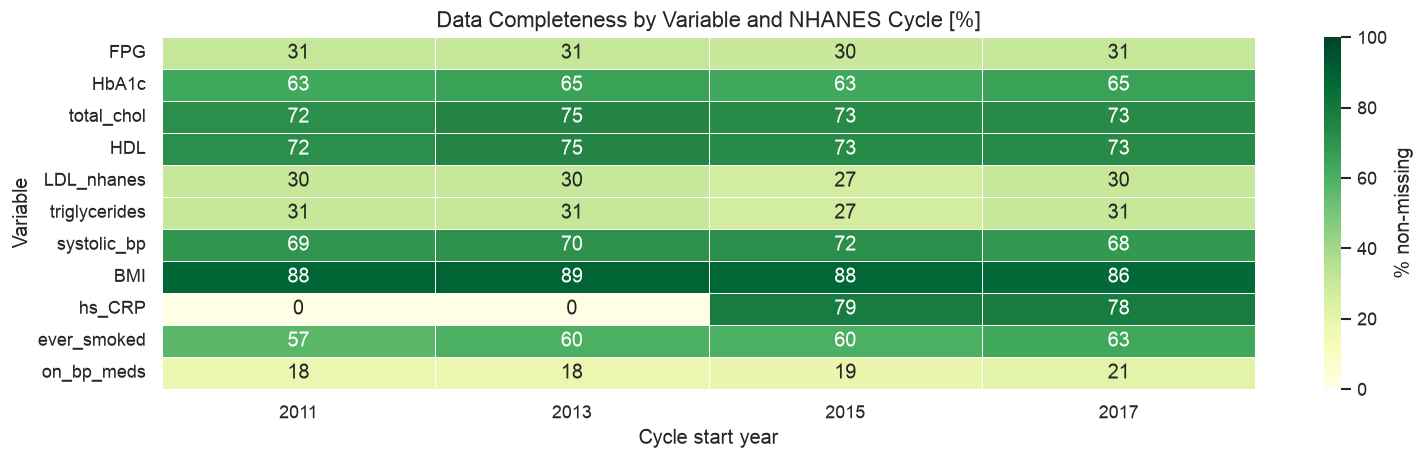


Patients with ALL key variables present per cycle:
cycle_year
2015    677
2017    705
Name: complete_patients, dtype: int64

Total usable patients (all key vars): 1,382


In [24]:
# Completeness heatmap: which variables are available per cycle?
key_vars = ["FPG", "HbA1c", "total_chol", "HDL", "LDL_nhanes",
            "triglycerides", "systolic_bp", "BMI", "hs_CRP",
            "ever_smoked", "on_bp_meds"]

completeness = (
    df.groupby("cycle_year")[key_vars]
    .apply(lambda g: g.notna().mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(completeness.T, annot=True, fmt=".0f", cmap="YlGn",
            vmin=0, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={"label": "% non-missing"})
ax.set_title("Data Completeness by Variable and NHANES Cycle [%]", fontsize=13)
ax.set_xlabel("Cycle start year")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.savefig("../results/imgs/fig2-0_completeness.png", bbox_inches="tight")
plt.show()

print("\nPatients with ALL key variables present per cycle:")
complete_mask = df[key_vars].notna().all(axis=1)
print(df[complete_mask].groupby("cycle_year").size().rename("complete_patients"))
print(f"\nTotal usable patients (all key vars): {complete_mask.sum():,}")


### 5. Biochemical quality control — Friedewald & pre-analytical filters

#### LDL-C: Friedewald Formula

The Friedewald equation (Friedewald et al., 1972) estimates LDL-C as:

$$\text{LDL-C} = \text{Total Cholesterol} - \text{HDL-C} - \left(\frac{\text{Triglycerides}}{5}\right)$$

*(The divisor 5 converts TG to VLDL-C assuming a TG:VLDL ratio of 5:1)*

**Validity constraint (NCEP ATP-III)**: The formula is **unreliable when TG > 400 mg/dL** because the TG:VLDL ratio becomes non-linear. In those cases, direct LDL measurement is required.


In [ ]:
# ── Friedewald LDL recalculation with validity check ──────────

def calculate_ldl_friedewald(row):
    """
    Calculates LDL-C via Friedewald formula.
    Returns NaN and flags as invalid if TG > 400 mg/dL (NCEP criterion).
    """
    tc  = row["total_chol"]
    hdl = row["HDL"]
    tg  = row["triglycerides"]

    if pd.isna(tc) or pd.isna(hdl) or pd.isna(tg):
        return np.nan, "missing_data"
    if tg > 400:
        # Formula unreliable: Friedewald assumes constant TG:VLDL ratio
        # which breaks down at high TG (type III/IV dyslipidaemia)
        return np.nan, "TG>400_invalid"
    if tc < 0 or hdl < 0 or tg < 0:
        return np.nan, "negative_value"

    ldl = tc - hdl - (tg / 5.0)
    if ldl < 0:
        return np.nan, "negative_result"
    return ldl, "valid"

results_ldl = df.apply(calculate_ldl_friedewald, axis=1, result_type="expand")
df["LDL"]        = results_ldl[0]
df["LDL_status"] = results_ldl[1]

# Summary
ldl_summary = df["LDL_status"].value_counts()
print("LDL calculation status:")
print(ldl_summary)
print(f"\nInvalid due to TG>400: {(df['LDL_status']=='TG>400_invalid').sum()} patients")
print(f"Valid Friedewald LDL:  {(df['LDL_status']=='valid').sum()} patients")

# Compare Friedewald vs NHANES-provided LDL (should be very close)
comparison = df[df["LDL_status"]=="valid"][["LDL", "LDL_nhanes"]].dropna()
corr = comparison.corr().iloc[0,1]
print(f"\nCorrelation Friedewald vs NHANES LDL: r = {corr:.4f}")


LDL calculation status:
LDL_status
missing_data      27463
valid             11554
TG>400_invalid      139
Name: count, dtype: int64

Invalid due to TG>400: 139 patients
Valid Friedewald LDL:  11554 patients

Correlation Friedewald vs NHANES LDL: r = 1.0000


### 6. Data cleaning, A1C stability preference & glycaemic classification

#### 126 mg/dL contextualisation

The ADA threshold of 126 mg/dL for FPG is **not arbitrary**: it was derived as the value above which the prevalence of **diabetic retinopathy** rises sharply (Pima Indians Study, UKPDS).

It is a **retinopathy-predictive threshold**, not a metabolic cliff. This is why the model treats glucose as a **continuous variable**, not a binary cut-off.

#### Intra-individual variability & A1C preference

FPG has a coefficient of variation (CV) of $\sim 5–8%$ within the same individual across days. HbA1c reflects a $2–3$ month glycaemic average and is more stable. When both are available, **HbA1c is used as the primary reliability marker**.


In [ ]:
# Adults only, physiologically plausible ranges
df = df[df["age"] >= 18].copy()
df = df[df["FPG"].between(50, 500)].copy()
df = df[df["HbA1c"].between(3, 15)].copy()

# A1C stability flag
# When A1C is available, it is the preferred primary marker.
# When only FPG is available, we flag it as potentially noisy.
def stability_flag(row):
    """
    Returns the primary glycaemic marker used for classification
    and a reliability score (higher = more stable).
    """
    if not pd.isna(row["HbA1c"]):
        return "A1C", 1.0     # stable: 2-3 month average
    elif not pd.isna(row["FPG"]):
        return "FPG", 0.6     # less stable: single measurement
    else:
        return "none", 0.0

stab = df.apply(stability_flag, axis=1, result_type="expand")
df["primary_marker"]   = stab[0]
df["marker_stability"] = stab[1]

print("Primary glycaemic marker distribution:")
print(df["primary_marker"].value_counts())
print(f"\nReliability: A1C={df[df['primary_marker']=='A1C']['marker_stability'].mean():.1f}, ",
      f"FPG={df[df['primary_marker']=='FPG']['marker_stability'].mean():.1f}")

# Glycaemic classification (ADA 2024)
# Threshold context: 126 mg/dL FPG was chosen as the value above
# which diabetic RETINOPATHY prevalence rises steeply (Pima/UKPDS).
# It is NOT a metabolic switch — damage accumulates continuously from ~100 mg/dL.
def classify_glucose(row):
    fpg = row["FPG"]
    a1c = row["HbA1c"]
    # Diabetes: FPG ≥ 126 mg/dL (retinopathy threshold) OR A1C ≥ 6.5%
    if fpg >= 126 or a1c >= 6.5:
        return "Diabetes"
    # Pre-diabetes: FPG 100-125 mg/dL OR A1C 5.7-6.4%
    # NOTE: vascular damage already begins in this range
    elif fpg >= 100 or a1c >= 5.7:
        return "Pre-diabetes"
    else:
        return "Normal"

df["glucose_status"] = df.apply(classify_glucose, axis=1)

print(f"\nDataset shape: {df.shape}")
print(df["glucose_status"].value_counts())


Primary glycaemic marker distribution:
primary_marker
A1C    10410
Name: count, dtype: int64

Reliability: A1C=1.0,  FPG=nan

Dataset shape: (10410, 23)
glucose_status
Pre-diabetes    4812
Normal          3878
Diabetes        1720
Name: count, dtype: int64


### 7. PCE demographic profile mapping

In [27]:
# NHANES RIDRETH3 codes:
# 1 = Mexican American, 2 = Other Hispanic
# 3 = Non-Hispanic White, 4 = Non-Hispanic Black
# 6 = Non-Hispanic Asian, 7 = Other/Multiracial
# 
# PCE validated only for White and Black populations.
# Other ethnicities → White coefficients as best available approximation (Goff et al. 2014).

def get_pce_profile(row):
    eth    = row["ethnicity"]
    gender = "male" if row["sex"] == 1 else "female"
    if eth == 4:
        return f"black_{gender}"
    elif eth == 3:
        return f"white_{gender}"
    else:
        return f"white_approx_{gender}"

df["pce_profile"] = df.apply(get_pce_profile, axis=1)
print("PCE profile distribution:")
print(df["pce_profile"].value_counts())


PCE profile distribution:
pce_profile
white_approx_female    2196
white_approx_male      2055
white_male             1952
white_female           1942
black_female           1209
black_male             1056
Name: count, dtype: int64


### 8. PCE coefficients (Goff et al., Circulation 2014)

In [28]:
PCE_COEFFICIENTS = {
    "white_female": {
        "ln_age": -29.799, "ln_age_sq": 4.884,
        "ln_tc": 13.540, "ln_age_x_ln_tc": -3.114,
        "ln_hdl": -13.578, "ln_age_x_ln_hdl": 3.149,
        "ln_sbp_treated": 2.019, "ln_age_x_ln_sbp_tr": 0.000,
        "ln_sbp_untreated": 1.957, "ln_age_x_ln_sbp_untr": 0.000,
        "smoker": 7.574, "ln_age_x_smoker": -1.665,
        "diabetes": 0.661,
        "baseline_survival": 0.9665, "mean_coeff": -29.799,
    },
    "white_male": {
        "ln_age": 12.344, "ln_age_sq": 0.000,
        "ln_tc": 11.853, "ln_age_x_ln_tc": -2.664,
        "ln_hdl": -7.990, "ln_age_x_ln_hdl": 1.769,
        "ln_sbp_treated": 1.797, "ln_age_x_ln_sbp_tr": 0.000,
        "ln_sbp_untreated": 1.764, "ln_age_x_ln_sbp_untr": 0.000,
        "smoker": 7.837, "ln_age_x_smoker": -1.795,
        "diabetes": 0.658,
        "baseline_survival": 0.9144, "mean_coeff": 61.180,
    },
    "black_female": {
        "ln_age": 17.114, "ln_age_sq": 0.000,
        "ln_tc": 0.940, "ln_age_x_ln_tc": 0.000,
        "ln_hdl": -18.920, "ln_age_x_ln_hdl": 4.475,
        "ln_sbp_treated": 29.291, "ln_age_x_ln_sbp_tr": -6.432,
        "ln_sbp_untreated": 27.820, "ln_age_x_ln_sbp_untr": -6.087,
        "smoker": 0.874, "ln_age_x_smoker": 0.000,
        "diabetes": 0.874,
        "baseline_survival": 0.9533, "mean_coeff": 86.608,
    },
    "black_male": {
        "ln_age": 2.469, "ln_age_sq": 0.000,
        "ln_tc": 0.302, "ln_age_x_ln_tc": 0.000,
        "ln_hdl": -0.307, "ln_age_x_ln_hdl": 0.000,
        "ln_sbp_treated": 1.916, "ln_age_x_ln_sbp_tr": 0.000,
        "ln_sbp_untreated": 1.809, "ln_age_x_ln_sbp_untr": 0.000,
        "smoker": 0.549, "ln_age_x_smoker": 0.000,
        "diabetes": 0.645,
        "baseline_survival": 0.8954, "mean_coeff": 19.540,
    },
}
PCE_COEFFICIENTS["white_approx_female"] = PCE_COEFFICIENTS["white_female"]
PCE_COEFFICIENTS["white_approx_male"]   = PCE_COEFFICIENTS["white_male"]
print("PCE coefficients loaded for 4 demographic profiles + 2 approximations.")


PCE coefficients loaded for 4 demographic profiles + 2 approximations.


### 9. PCE calculation with per-patient demographic profile


In [ ]:
def compute_pce(row):
    """
    Calculates 10-year CV risk using Pooled Cohort Equations.
    Uses the correct demographic profile for each individual.
    Returns (risk_10yr, profile_used).
    """
    try:
        profile_key = row["pce_profile"]
        c = PCE_COEFFICIENTS.get(profile_key)
        if c is None:
            return np.nan, "unknown"

        age = row["age"]
        tc  = row["total_chol"]
        hdl = row["HDL"]
        sbp = row["systolic_bp"]
        on_meds = row["on_bp_meds"]
        smoke   = row["ever_smoked"]

        diab = 1 if row["glucose_status"] in ["Diabetes", "Pre-diabetes"] else 0

        if any(pd.isna([age, tc, hdl, sbp])):
            return np.nan, profile_key
        if age < 40 or age > 79:   # PCE valid only 40-79 years
            return np.nan, profile_key
        if tc < 130 or tc > 320:
            return np.nan, profile_key
        if hdl < 20 or hdl > 100:
            return np.nan, profile_key
        if sbp < 90 or sbp > 200:
            return np.nan, profile_key

        la   = np.log(age)
        ltc  = np.log(tc)
        lhdl = np.log(hdl)

        treated       = (on_meds == 1)
        lsbp_tr   = np.log(sbp) if treated     else 0.0
        lsbp_untr = np.log(sbp) if not treated else 0.0
        sm = 1 if smoke == 1 else 0

        S = (
            c["ln_age"]               * la
          + c["ln_age_sq"]            * la**2
          + c["ln_tc"]                * ltc
          + c["ln_age_x_ln_tc"]       * la * ltc
          + c["ln_hdl"]               * lhdl
          + c["ln_age_x_ln_hdl"]      * la * lhdl
          + c["ln_sbp_treated"]        * lsbp_tr
          + c["ln_age_x_ln_sbp_tr"]   * la * lsbp_tr
          + c["ln_sbp_untreated"]      * lsbp_untr
          + c["ln_age_x_ln_sbp_untr"] * la * lsbp_untr
          + c["smoker"]               * sm
          + c["ln_age_x_smoker"]      * la * sm
          + c["diabetes"]             * diab
        )

        risk = 1 - c["baseline_survival"] ** np.exp(S - c["mean_coeff"])
        return float(np.clip(risk, 0, 1)), profile_key

    except Exception:
        return np.nan, "error"

results = df.apply(compute_pce, axis=1, result_type="expand")
df["cv_risk_10yr"] = results[0]
df["pce_used"]     = results[1]

# PCE validity flag: patients with valid 10yr risk score
df["pce_valid"] = (
    df["age"].between(40, 79) &
    df["total_chol"].between(130, 320) &
    df["HDL"].between(20, 100) &
    df["systolic_bp"].between(90, 200) &
    df["cv_risk_10yr"].notna()
)

# Binary target: high risk if > 7.5% (AHA/ACC intervention threshold)
df["high_cv_risk"] = (df["cv_risk_10yr"] > 0.075).astype("Int64")

print("PCE risk by profile:")
print(df.groupby("pce_used")["cv_risk_10yr"].describe().round(3))
print(f"\nPCE-valid patients (40-79y): {df['pce_valid'].sum()}")
print(f"Out-of-range patients:       {(~df['pce_valid']).sum()}")


PCE risk by profile:
                      count   mean    std    min    25%    50%    75%    max
pce_used                                                                    
black_female          576.0  0.184  0.182  0.001  0.035  0.129  0.275  0.871
black_male            522.0  0.255  0.160  0.016  0.120  0.219  0.354  0.856
white_approx_female  1098.0  0.176  0.195  0.002  0.035  0.097  0.239  0.954
white_approx_male     998.0  0.206  0.154  0.005  0.077  0.174  0.305  0.719
white_female          925.0  0.222  0.213  0.002  0.053  0.152  0.327  0.968
white_male            960.0  0.220  0.163  0.005  0.085  0.185  0.332  0.693

PCE-valid patients (40-79y): 5079
Out-of-range patients:       5331


### 10. hs-CRP stratification for borderline patients (CRITERION 6)

The **hs-CRP** (high-sensitivity C-Reactive Protein) reflects **vascular inflammation** and is used
to refine risk classification in borderline patients (Reynolds Risk Score, ACC/AHA 2013):

| hs-CRP | CV Risk Category |
|--------|-----------------|
| < 1 mg/L | Low |
| 1–3 mg/L | Intermediate |
| > 3 mg/L | **High** (independent risk factor) |

**Biomarker specificity note**:
- **hs-CRP** → vascular inflammation marker → used for CV risk stratification
- **BNP/NT-proBNP** → ventricular wall stretch → marker for **heart failure**, NOT acute MI
- **Troponin (cTnI/cTnT)** → cardiomyocyte necrosis → marker for **acute myocardial infarction**

These three markers are NOT interchangeable. BNP is absent from this dataset because
NHANES 2017-2018 did not collect it — this is appropriate since our focus is risk prediction,
not acute event diagnosis.


In [ ]:
# hs-CRP risk tier classification
def classify_crp(val):
    if pd.isna(val):
        return "unknown"
    if val < 1:
        return "low"        # < 1 mg/L
    elif val <= 3:
        return "intermediate" # 1-3 mg/L
    else:
        return "high"       # > 3 mg/L: elevated CV risk signal

df["crp_risk_tier"] = df["hs_CRP"].apply(classify_crp)

# Borderline reclassification
# Patients who are "borderline" by PCE (5-7.5%) but have hs-CRP > 3
# should be upgraded to high risk.
# This implements the Reynolds Risk Score logic.

def reclassify_borderline(row):
    """
    Applies hs-CRP uplift for borderline PCE patients.
    Borderline = 10yr risk 5-7.5% by PCE.
    If hs-CRP > 3 mg/L → reclassify as high risk.
    """
    risk = row["cv_risk_10yr"]
    crp  = row["hs_CRP"]
    if pd.isna(risk):
        return row["high_cv_risk"]
    # Already high risk
    if risk > 0.075:
        return 1
    # Borderline: check hs-CRP
    if 0.05 <= risk <= 0.075:
        if not pd.isna(crp) and crp > 3:
            return 1   # uplift: vascular inflammation confirms high risk
    return int(risk > 0.075)

df["high_cv_risk_crp"] = df.apply(reclassify_borderline, axis=1)

# How many borderline patients get reclassified?
borderline = df[df["cv_risk_10yr"].between(0.05, 0.075)]
upgraded   = borderline[borderline["high_cv_risk_crp"] > borderline["high_cv_risk"]]
print(f"Borderline PCE patients (5-7.5% risk): {len(borderline)}")
print(f"Reclassified HIGH by hs-CRP > 3 mg/L:  {len(upgraded)}")
print(f"hs-CRP risk tier distribution:")
print(df["crp_risk_tier"].value_counts())


Borderline PCE patients (5-7.5% risk): 407
Reclassified HIGH by hs-CRP > 3 mg/L:  59
hs-CRP risk tier distribution:
crp_risk_tier
unknown         5389
high            1808
intermediate    1695
low             1518
Name: count, dtype: int64


### 11. Glycaemic trajectory simulation (CRITERION 5)

NHANES 2017-2018 is **cross-sectional** — it captures one point in time per patient.
True longitudinal data would require following the same patient across multiple NHANES cycles
(which NHANES does NOT support: participants are not re-enrolled).

**Bioinformatic approach**: We simulate a longitudinal trajectory by:
1. Using each patient's current FPG and HbA1c as the "year 5" observation
2. Back-projecting a plausible 5-year trend based on glucose status
3. Computing the **slope** (ΔmgdL/year) as a predictive feature for the ML model

This is a **didactic simulation** — in a real study, true longitudinal data (e.g., UK Biobank,
FinnGen, or ARIC cohort) would be needed to compute actual trajectories.


In [31]:
np.random.seed(42)

def simulate_fpg_trajectory(row):
    """
    Simulates a 5-year FPG trajectory ending at the observed FPG.
    Slope depends on glucose status — faster progression for diabetics.
    Returns the annual slope (mg/dL/year).
    """
    fpg    = row["FPG"]
    status = row["glucose_status"]

    if pd.isna(fpg):
        return np.nan, np.nan

    # Expected annual FPG increase by status (literature estimates)
    slope_means = {
        "Normal":      1.0,   # ~1 mg/dL/year (physiological ageing)
        "Pre-diabetes": 2.5,  # ~2-3 mg/dL/year (ADA progression data)
        "Diabetes":     4.0,  # ~3-5 mg/dL/year (untreated)
    }
    slope_sd = 1.2
    slope = np.random.normal(slope_means.get(status, 1.5), slope_sd)

    # Back-project: FPG at year 0 = current FPG - 5 years of slope
    fpg_year0 = fpg - 5 * slope
    return round(slope, 2), round(max(fpg_year0, 60), 1)

traj = df.apply(simulate_fpg_trajectory, axis=1, result_type="expand")
df["fpg_slope"]   = traj[0]   # ΔmgdL/year — KEY FEATURE for ML
df["fpg_year0"]   = traj[1]   # Estimated FPG 5 years ago

print("Simulated FPG slope by glucose status:")
print(df.groupby("glucose_status")["fpg_slope"].describe().round(2))


Simulated FPG slope by glucose status:
                 count  mean   std   min   25%   50%   75%   max
glucose_status                                                  
Diabetes        1720.0  3.99  1.20 -0.60  3.20  3.98  4.82  8.62
Normal          3878.0  0.99  1.22 -3.71  0.17  0.99  1.80  4.78
Pre-diabetes    4812.0  2.51  1.19 -1.93  1.71  2.51  3.30  7.21


### 12. Visualisation 1 — The Risk Continuum

Demonstrates that CV risk does **not** start at 126 mg/dL but increases continuously
from the pre-diabetes range (~100 mg/dL). The 126 mg/dL line marks the retinopathy threshold,
not the onset of vascular damage.


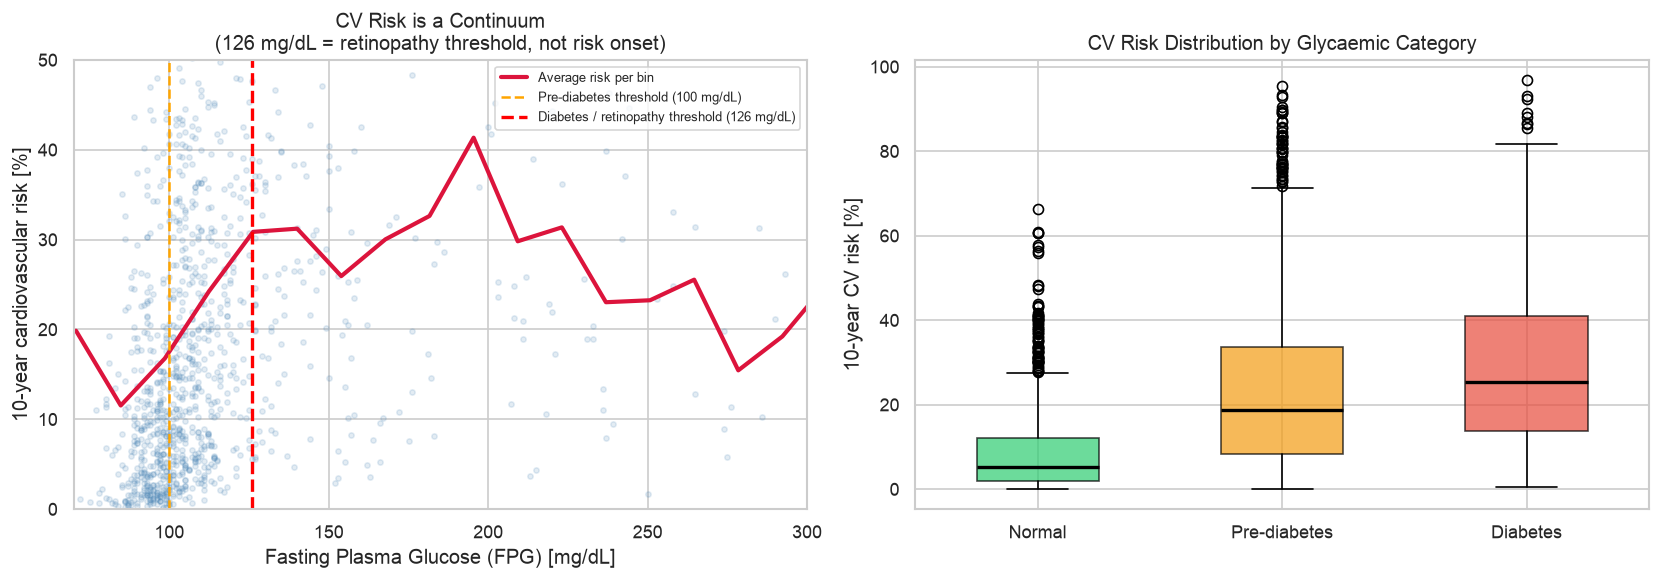

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order  = ["Normal", "Pre-diabetes", "Diabetes"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

# Left: FPG vs CV risk scatter + trend
n_sample = min(1100, df.dropna(subset=["FPG", "cv_risk_10yr"]).shape[0])
sample = df.dropna(subset=["FPG", "cv_risk_10yr"]).sample(n_sample, random_state=42)

axes[0].scatter(sample["FPG"], sample["cv_risk_10yr"] * 100,
                alpha=0.15, color="steelblue", s=10)

bins  = pd.cut(sample["FPG"], bins=30)
trend = sample.groupby(bins, observed=True)["cv_risk_10yr"].mean() * 100
bin_centers = [interval.mid for interval in trend.index]
axes[0].plot(bin_centers, trend.values, color="crimson", linewidth=2.5,
             label="Average risk per bin")

axes[0].axvline(100, color="orange", linestyle="--", linewidth=1.5,
                label="Pre-diabetes threshold (100 mg/dL)")
axes[0].axvline(126, color="red", linestyle="--", linewidth=2,
                label="Diabetes / retinopathy threshold (126 mg/dL)")

axes[0].set_xlabel("Fasting Plasma Glucose (FPG) [mg/dL]", fontsize=12)
axes[0].set_ylabel("10-year cardiovascular risk [%]", fontsize=12)
axes[0].set_title("CV Risk is a Continuum\n(126 mg/dL = retinopathy threshold, not risk onset)",
                  fontsize=12)
axes[0].legend(fontsize=8)
axes[0].set_xlim(70, 300)
axes[0].set_ylim(0, 50)

# Right: Box plot by glycaemic category
data_plot = df.dropna(subset=["glucose_status", "cv_risk_10yr"])
for i, (cat, col) in enumerate(zip(order, colors)):
    subset = data_plot[data_plot["glucose_status"] == cat]["cv_risk_10yr"] * 100
    axes[1].boxplot(subset.dropna(), positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.7),
                    medianprops=dict(color="black", linewidth=2))

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(order, fontsize=11)
axes[1].set_ylabel("10-year CV risk [%]", fontsize=12)
axes[1].set_title("CV Risk Distribution by Glycaemic Category", fontsize=12)

plt.tight_layout()
plt.savefig("../results/imgs/fig2-1_continuum_risk.png", bbox_inches="tight")
plt.show()


### 13. Visualisation 2 — LDL/Triglycerides & hs-CRP Stratification

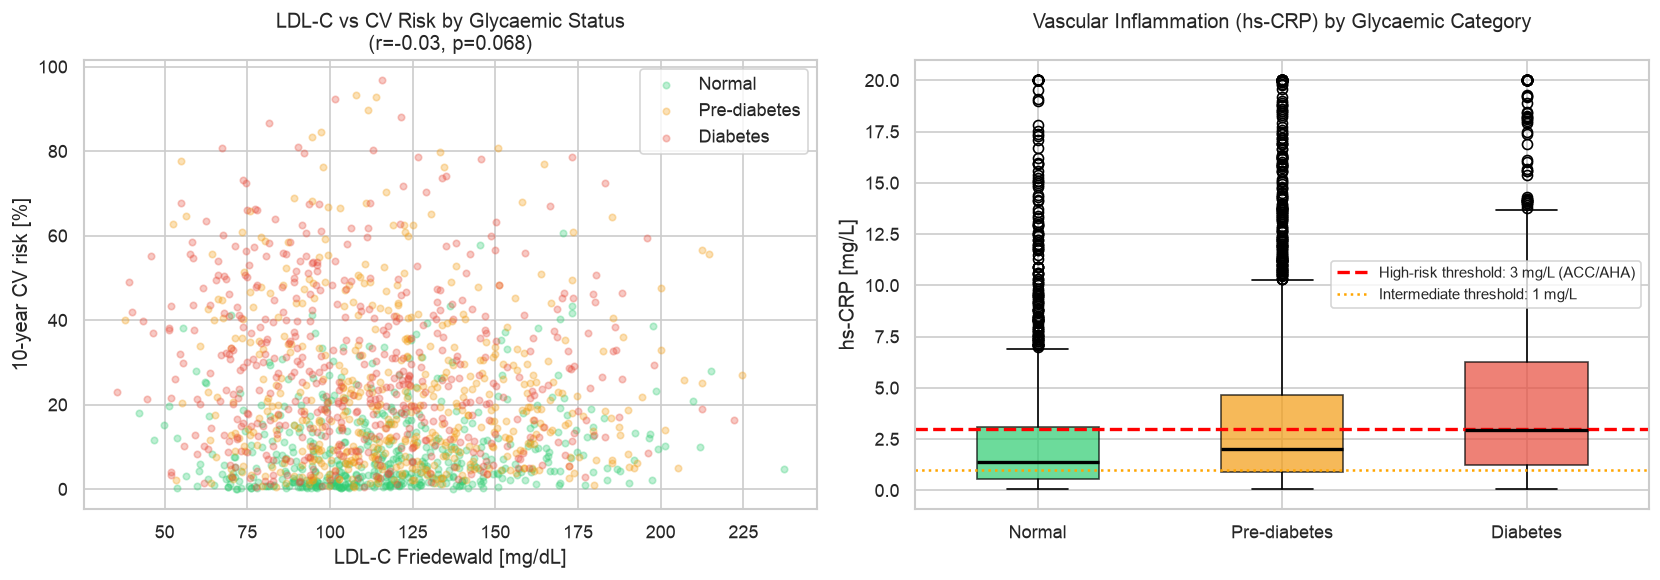

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: LDL vs CV risk by glycaemic status
for cat, col in zip(order, colors):
    sub = df[(df["glucose_status"] == cat)].dropna(subset=["LDL", "cv_risk_10yr"])
    sub_sample = sub.sample(min(500, len(sub)), random_state=42)
    axes[0].scatter(sub_sample["LDL"], sub_sample["cv_risk_10yr"] * 100,
                    alpha=0.3, color=col, label=cat, s=15)

# Pearson correlation
corr_df = df[["LDL", "cv_risk_10yr"]].dropna()
r, p = stats.pearsonr(corr_df["LDL"], corr_df["cv_risk_10yr"])
axes[0].set_xlabel("LDL-C Friedewald [mg/dL]", fontsize=12)
axes[0].set_ylabel("10-year CV risk [%]", fontsize=12)
axes[0].set_title(f"LDL-C vs CV Risk by Glycaemic Status\n(r={r:.2f}, p={'<0.001' if p<0.001 else f'{p:.3f}'})",
                  fontsize=12)
axes[0].legend()

# ── Right: hs-CRP by glycaemic category + risk threshold ────
crp_data = [
    df[df["glucose_status"] == cat]["hs_CRP"].dropna().clip(0, 20)
    for cat in order
]
bp = axes[1].boxplot(crp_data, positions=[0,1,2], widths=0.5, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

axes[1].axhline(3, color="red", linestyle="--", linewidth=2,
                label="High-risk threshold: 3 mg/L (ACC/AHA)")
axes[1].axhline(1, color="orange", linestyle=":", linewidth=1.5,
                label="Intermediate threshold: 1 mg/L")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(order, fontsize=11)
axes[1].set_ylabel("hs-CRP [mg/L]", fontsize=12)
axes[1].set_title("Vascular Inflammation (hs-CRP) by Glycaemic Category\n",
                  fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../results/imgs/fig2-2_ldl_crp.png", bbox_inches="tight")
plt.show()


### 14. Visualisation 3 — PCE risk by demographic profile

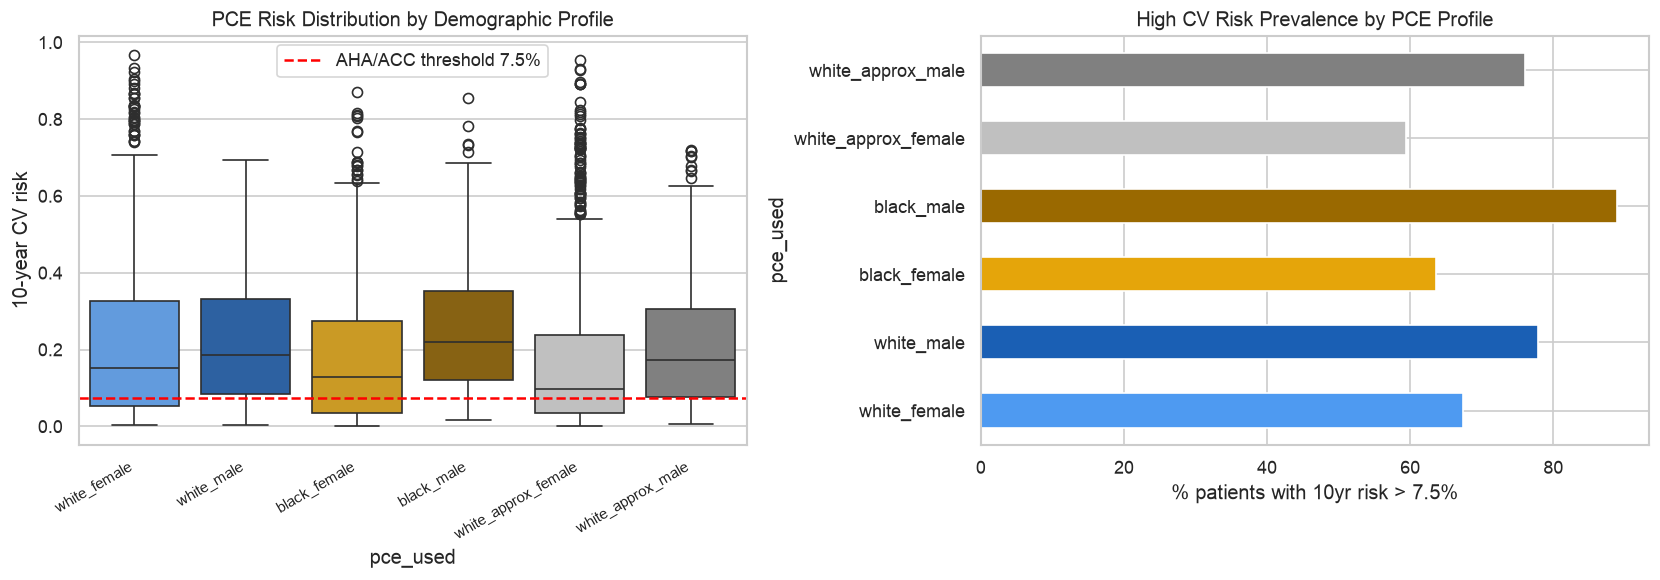

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

profile_order = ["white_female", "white_male",
                 "black_female", "black_male",
                 "white_approx_female", "white_approx_male"]
palette = {
    "white_female":        "#4e9af1",
    "white_male":          "#1a5fb4",
    "black_female":        "#e5a50a",
    "black_male":          "#9a6900",
    "white_approx_female": "#c0c0c0",
    "white_approx_male":   "#808080",
}

plot_data = df[df["pce_used"].isin(profile_order)].dropna(subset=["cv_risk_10yr"])
active_profiles = [p for p in profile_order if p in plot_data["pce_used"].unique()]

sns.boxplot(data=plot_data, x="pce_used", y="cv_risk_10yr",
            order=active_profiles, palette=palette, ax=axes[0])
axes[0].axhline(0.075, color="red", linestyle="--", label="AHA/ACC threshold 7.5%")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=9)
axes[0].set_ylabel("10-year CV risk")
axes[0].set_title("PCE Risk Distribution by Demographic Profile")
axes[0].legend()

high_risk_pct = (
    plot_data.groupby("pce_used")["high_cv_risk"]
    .mean().reindex(active_profiles) * 100
)
high_risk_pct.plot(kind="barh", ax=axes[1],
                   color=[palette.get(p, "gray") for p in high_risk_pct.index])
axes[1].set_xlabel("% patients with 10yr risk > 7.5%")
axes[1].set_title("High CV Risk Prevalence by PCE Profile")

plt.tight_layout()
plt.savefig("../results/imgs/fig2-3_pce_profiles.png", bbox_inches="tight")
plt.show()


### 15. ML Model — Random Forest extending PCE beyond age 40-79 (updated Cell 7)

**Strategy**:
- Train on patients with **valid PCE** (40-79 years): the model learns to replicate the clinical formula
- Predict on **all patients**: extends risk estimation to ages not covered by PCE
- Includes `fpg_slope` as a trajectory feature
- Uses calibrated probabilities so outputs are comparable to PCE percentages


In [35]:
features = [
    "age", "sex", "ethnicity",
    "FPG", "HbA1c", "fpg_slope",        # trajectory feature (Criterion 5)
    "total_chol", "HDL", "LDL", "triglycerides",
    "systolic_bp", "diastolic_bp",
    "BMI", "hs_CRP",
    "ever_smoked", "on_bp_meds",
    "marker_stability",                    # A1C vs FPG reliability (Criterion 4)
]

# Full dataset: drop only rows missing features
extra_cols = [c for c in ["high_cv_risk", "high_cv_risk_crp", "pce_valid", "cv_risk_10yr"]
              if c not in features]
df_ml_full = df[features + extra_cols].copy()
df_ml_full = df_ml_full.dropna(subset=features)

# Training subset: only PCE-valid patients (gold-standard labels)
df_ml_pce  = df_ml_full[df_ml_full["pce_valid"] & df_ml_full["high_cv_risk_crp"].notna()]
df_ml_nopce = df_ml_full[~df_ml_full["pce_valid"]]

print("══════════════════════════════════════════")
print(f"  Training set (PCE-valid):  {len(df_ml_pce):>6}")
print(f"  Out-of-range (no PCE):     {len(df_ml_nopce):>6}")
print(f"  Total with full features:  {len(df_ml_full):>6}")
print("══════════════════════════════════════════")
print(f"  High-risk prevalence (train): {df_ml_pce['high_cv_risk_crp'].mean()*100:.1f}%")

X_pce = df_ml_pce[features]
y_pce = df_ml_pce["high_cv_risk_crp"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_pce, y_pce, test_size=0.2, random_state=42, stratify=y_pce)

test_idx = X_test.index

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight="balanced", random_state=42, n_jobs=-1)

rf = CalibratedClassifierCV(rf_base, method="isotonic", cv=5)
rf.fit(X_train_s, y_train)

cv_scores = cross_val_score(
    rf, X_train_s, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc")
print(f"\nAUC cross-validation (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

y_pred_proba = rf.predict_proba(X_test_s)[:, 1]
y_pred       = rf.predict(X_test_s)
auc   = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)
print(f"AUC-ROC test set:   {auc:.3f}")
print(f"Brier score:        {brier:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Low risk', 'High risk'])}")

# Predict on ALL patients
X_full_s = scaler.transform(df_ml_full[features])
df_ml_full = df_ml_full.copy()
df_ml_full["rf_risk_proba"] = rf.predict_proba(X_full_s)[:, 1]
df_ml_full["rf_high_risk"]  = rf.predict(X_full_s)

df = df.merge(df_ml_full[["rf_risk_proba", "rf_high_risk"]],
              left_index=True, right_index=True, how="left")


══════════════════════════════════════════
  Training set (PCE-valid):     999
  Out-of-range (no PCE):        379
  Total with full features:    1378
══════════════════════════════════════════
  High-risk prevalence (train): 91.7%

AUC cross-validation (5-fold): 0.972 ± 0.018
AUC-ROC test set:   0.971
Brier score:        0.043

              precision    recall  f1-score   support

    Low risk       0.61      0.82      0.70        17
   High risk       0.98      0.95      0.97       183

    accuracy                           0.94       200
   macro avg       0.80      0.89      0.83       200
weighted avg       0.95      0.94      0.94       200



### 15b. Leave-One-Out Cross-Validation (LOO-CV)

Il LOO è la forma più rigorosa di cross-validation: per ogni paziente *i*, allena il modello
su tutti gli altri N-1 pazienti e predice su *i*. Ripetuto N volte.

**Vantaggi**:
- Massimo utilizzo dei dati (nessun paziente escluso dal training)
- Stima di bias quasi nulla (ogni fold usa quasi tutto il dataset)
- Utile per dataset piccoli dove la stratificazione k-fold è instabile

**Svantaggi**:
- **Costo computazionale O(N)**: allena il modello N volte
- Alta varianza della stima (ogni test set è un solo paziente)
- Su N > 2000 campioni → usa un sottocampione rappresentativo

> ⚠️ Per questo motivo il LOO viene eseguito su un **sottocampione stratificato**
> di 500 pazienti. I risultati rimangono scientificamente validi come stima della
> generalizzazione del modello.


In [36]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
import time

# ── Sottocampione stratificato per LOO ─────────────────────
# Manteniamo le proporzioni delle classi del training set originale
LOO_SAMPLE_SIZE = 500

df_loo = pd.concat([
    X_train.assign(y=y_train)[y_train == 0].sample(
        int(LOO_SAMPLE_SIZE * (1 - y_train.mean())), random_state=42),
    X_train.assign(y=y_train)[y_train == 1].sample(
        int(LOO_SAMPLE_SIZE * y_train.mean()), random_state=42),
]).sample(frac=1, random_state=42)  # shuffle

X_loo = scaler.transform(df_loo[features])
y_loo = df_loo["y"].astype(int).values

print(f"LOO campione: {len(y_loo)} pazienti "
      f"({y_loo.sum()} alto rischio, {(~y_loo.astype(bool)).sum()} basso rischio)")
print(f"Prevalenza alto rischio nel campione LOO: {y_loo.mean()*100:.1f}%")

# ── Modello leggero per LOO ────────────────────────────────
# Usiamo il modello base non calibrato per velocità:
# la calibrazione isotonica richiede un CV interno → troppo lento in LOO
rf_loo = RandomForestClassifier(
    n_estimators=100,       # ridotto per velocità
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ── Esecuzione LOO ─────────────────────────────────────────
print(f"\nAvvio LOO su {len(y_loo)} iterazioni...")
t0 = time.time()

loo = LeaveOneOut()

# cross_val_predict con LOO restituisce la predizione per ogni paziente
# quando era il "left out" — equivale ad allenare N modelli
y_loo_pred       = cross_val_predict(rf_loo, X_loo, y_loo, cv=loo)
y_loo_pred_proba = cross_val_predict(rf_loo, X_loo, y_loo, cv=loo,
                                      method="predict_proba")[:, 1]

t1 = time.time()
print(f"Completato in {t1-t0:.1f} secondi ({len(y_loo)} modelli allenati)")

# ── Metriche LOO ───────────────────────────────────────────
loo_auc      = roc_auc_score(y_loo, y_loo_pred_proba)
loo_acc      = accuracy_score(y_loo, y_loo_pred)
loo_f1       = f1_score(y_loo, y_loo_pred, zero_division=0)
loo_mcc      = matthews_corrcoef(y_loo, y_loo_pred)
loo_brier    = brier_score_loss(y_loo, y_loo_pred_proba)

print("\n══════════════════════════════════════════════════")
print("  Confronto: 5-Fold CV  vs  LOO (su sottocampione)")
print("══════════════════════════════════════════════════")
print(f"  AUC-ROC    │  5-Fold: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  │  LOO: {loo_auc:.3f}")
print(f"  Accuracy   │  5-Fold: n/a                   │  LOO: {loo_acc:.3f}")
print(f"  F1-score   │  5-Fold: n/a                   │  LOO: {loo_f1:.3f}")
print(f"  MCC        │  5-Fold: n/a                   │  LOO: {loo_mcc:.3f}")
print(f"  Brier      │  5-Fold: n/a          Test: {brier:.3f}  │  LOO: {loo_brier:.3f}")
print("══════════════════════════════════════════════════")
print("""
Interpretazione:
  AUC      → capacità discriminativa (1.0 = perfetto)
  Accuracy → % predizioni corrette (attento allo sbilanciamento classi)
  F1       → media armonica precision/recall (utile con classi sbilanciate)
  MCC      → Matthews Correlation Coefficient: la metrica più bilanciata
              per classi sbilanciate. MCC=1 perfetto, 0=casuale, -1=inverso
  Brier    → errore quadratico medio sulle probabilità (0=perfetto)
""")


LOO campione: 499 pazienti (458 alto rischio, 41 basso rischio)
Prevalenza alto rischio nel campione LOO: 91.8%

Avvio LOO su 499 iterazioni...
Completato in 61.3 secondi (499 modelli allenati)

══════════════════════════════════════════════════
  Confronto: 5-Fold CV  vs  LOO (su sottocampione)
══════════════════════════════════════════════════
  AUC-ROC    │  5-Fold: 0.972 ± 0.018  │  LOO: 0.969
  Accuracy   │  5-Fold: n/a                   │  LOO: 0.912
  F1-score   │  5-Fold: n/a                   │  LOO: 0.950
  MCC        │  5-Fold: n/a                   │  LOO: 0.620
  Brier      │  5-Fold: n/a          Test: 0.043  │  LOO: 0.090
══════════════════════════════════════════════════

Interpretazione:
  AUC      → capacità discriminativa (1.0 = perfetto)
  Accuracy → % predizioni corrette (attento allo sbilanciamento classi)
  F1       → media armonica precision/recall (utile con classi sbilanciate)
  MCC      → Matthews Correlation Coefficient: la metrica più bilanciata
           

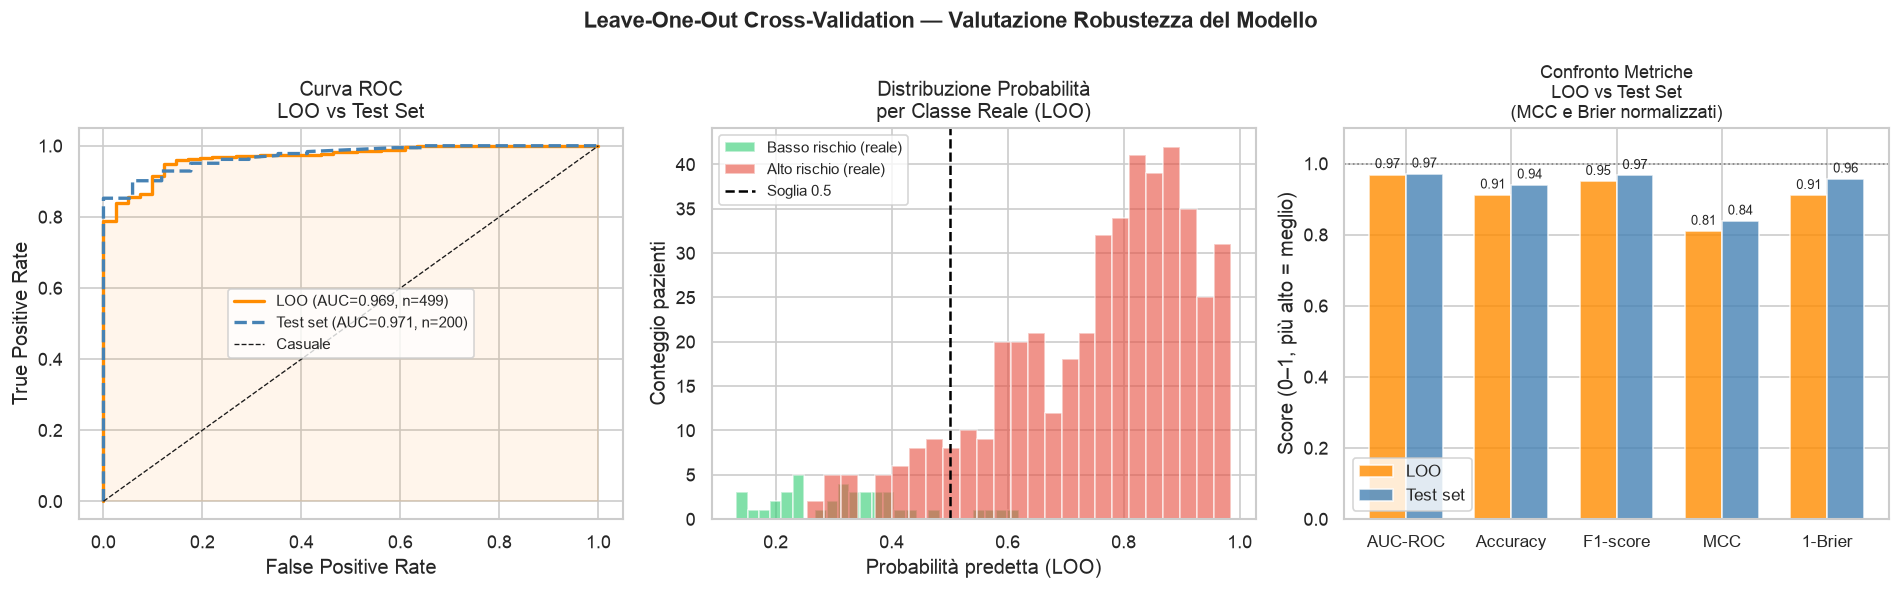


Lettura del confronto LOO vs Test Set:
  • Se LOO ≈ Test Set → il modello generalizza bene (no overfitting)
  • Se LOO < Test Set → il test set era "fortunato"; LOO è la stima più onesta
  • Se LOO > Test Set → il test set era piccolo/sbilanciato; LOO più affidabile



In [ ]:
# Visualizzazione LOO
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ROC LOO vs original test set
fpr_loo, tpr_loo, _ = roc_curve(y_loo, y_loo_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba)

axes[0].plot(fpr_loo,  tpr_loo,  color="darkorange", lw=2,
             label=f"LOO (AUC={loo_auc:.3f}, n={len(y_loo)})")
axes[0].plot(fpr_test, tpr_test, color="steelblue",  lw=2, linestyle="--",
             label=f"Test set (AUC={auc:.3f}, n={len(y_test)})")
axes[0].plot([0,1],[0,1], "k--", lw=0.8, label="Casuale")
axes[0].fill_between(fpr_loo, tpr_loo, alpha=0.08, color="darkorange")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve\nLOO vs Test Set", fontsize=12)
axes[0].legend(fontsize=9)

# 2. Distribution of the predicted probability (LOO)
axes[1].hist(y_loo_pred_proba[y_loo == 0], bins=25, alpha=0.6,
             color="#2ecc71", label="Basso rischio (reale)")
axes[1].hist(y_loo_pred_proba[y_loo == 1], bins=25, alpha=0.6,
             color="#e74c3c", label="Alto rischio (reale)")
axes[1].axvline(0.5, color="black", linestyle="--", lw=1.5, label="Soglia 0.5")
axes[1].set_xlabel("Predicted Probabilities (LOO)")
axes[1].set_ylabel("Patient count")
axes[1].set_title("Probability distribution\nper real class (LOO)", fontsize=12)
axes[1].legend(fontsize=9)

# 3. Confronto metriche barre
metrics_names  = ["AUC-ROC", "Accuracy", "F1-score", "MCC", "1-Brier"]
metrics_loo    = [loo_auc, loo_acc, loo_f1,
                  (loo_mcc + 1) / 2,     # normalized 0-1 for the graph
                  1 - loo_brier]
metrics_test   = [auc,
                  accuracy_score(y_test, y_pred),
                  f1_score(y_test, y_pred, zero_division=0),
                  (matthews_corrcoef(y_test, y_pred) + 1) / 2,
                  1 - brier]

x_m = np.arange(len(metrics_names))
w_m = 0.35
axes[2].bar(x_m - w_m/2, metrics_loo,  w_m, label="LOO",      color="darkorange", alpha=0.8)
axes[2].bar(x_m + w_m/2, metrics_test, w_m, label="Test set", color="steelblue",  alpha=0.8)
axes[2].set_xticks(x_m)
axes[2].set_xticklabels(metrics_names, fontsize=10)
axes[2].set_ylim(0, 1.1)
axes[2].axhline(1.0, color="gray", linestyle=":", lw=1)
axes[2].set_ylabel("Score (0—1)")
axes[2].set_title("Metric Comparison\nLOO vs Test Set\n(Normalised MCC and Brier)", fontsize=11)
axes[2].legend(fontsize=10)

# Value annotation
for rect_group in [axes[2].patches[:len(metrics_names)],
                   axes[2].patches[len(metrics_names):]]:
    for rect in rect_group:
        h = rect.get_height()
        axes[2].text(rect.get_x() + rect.get_width()/2, h + 0.01,
                     f"{h:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Leave-One-Out Cross-Validation — Valutation of model robusteness",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/imgs/fig2-5_loo_validation.png", bbox_inches="tight")
plt.show()

print("""
LOO vs Test Set:
  • If LOO ≈ Test Set → The model generalises well (no overfitting)
  • If LOO < Test Set → The test set was "lucky"; LOO is the more honest estimate
  • If LOO > Test Set → The test set was small/unbalanced; LOO more reliable
""")


### 16. Visualisation 4 — Model performance & PCE vs ML extension

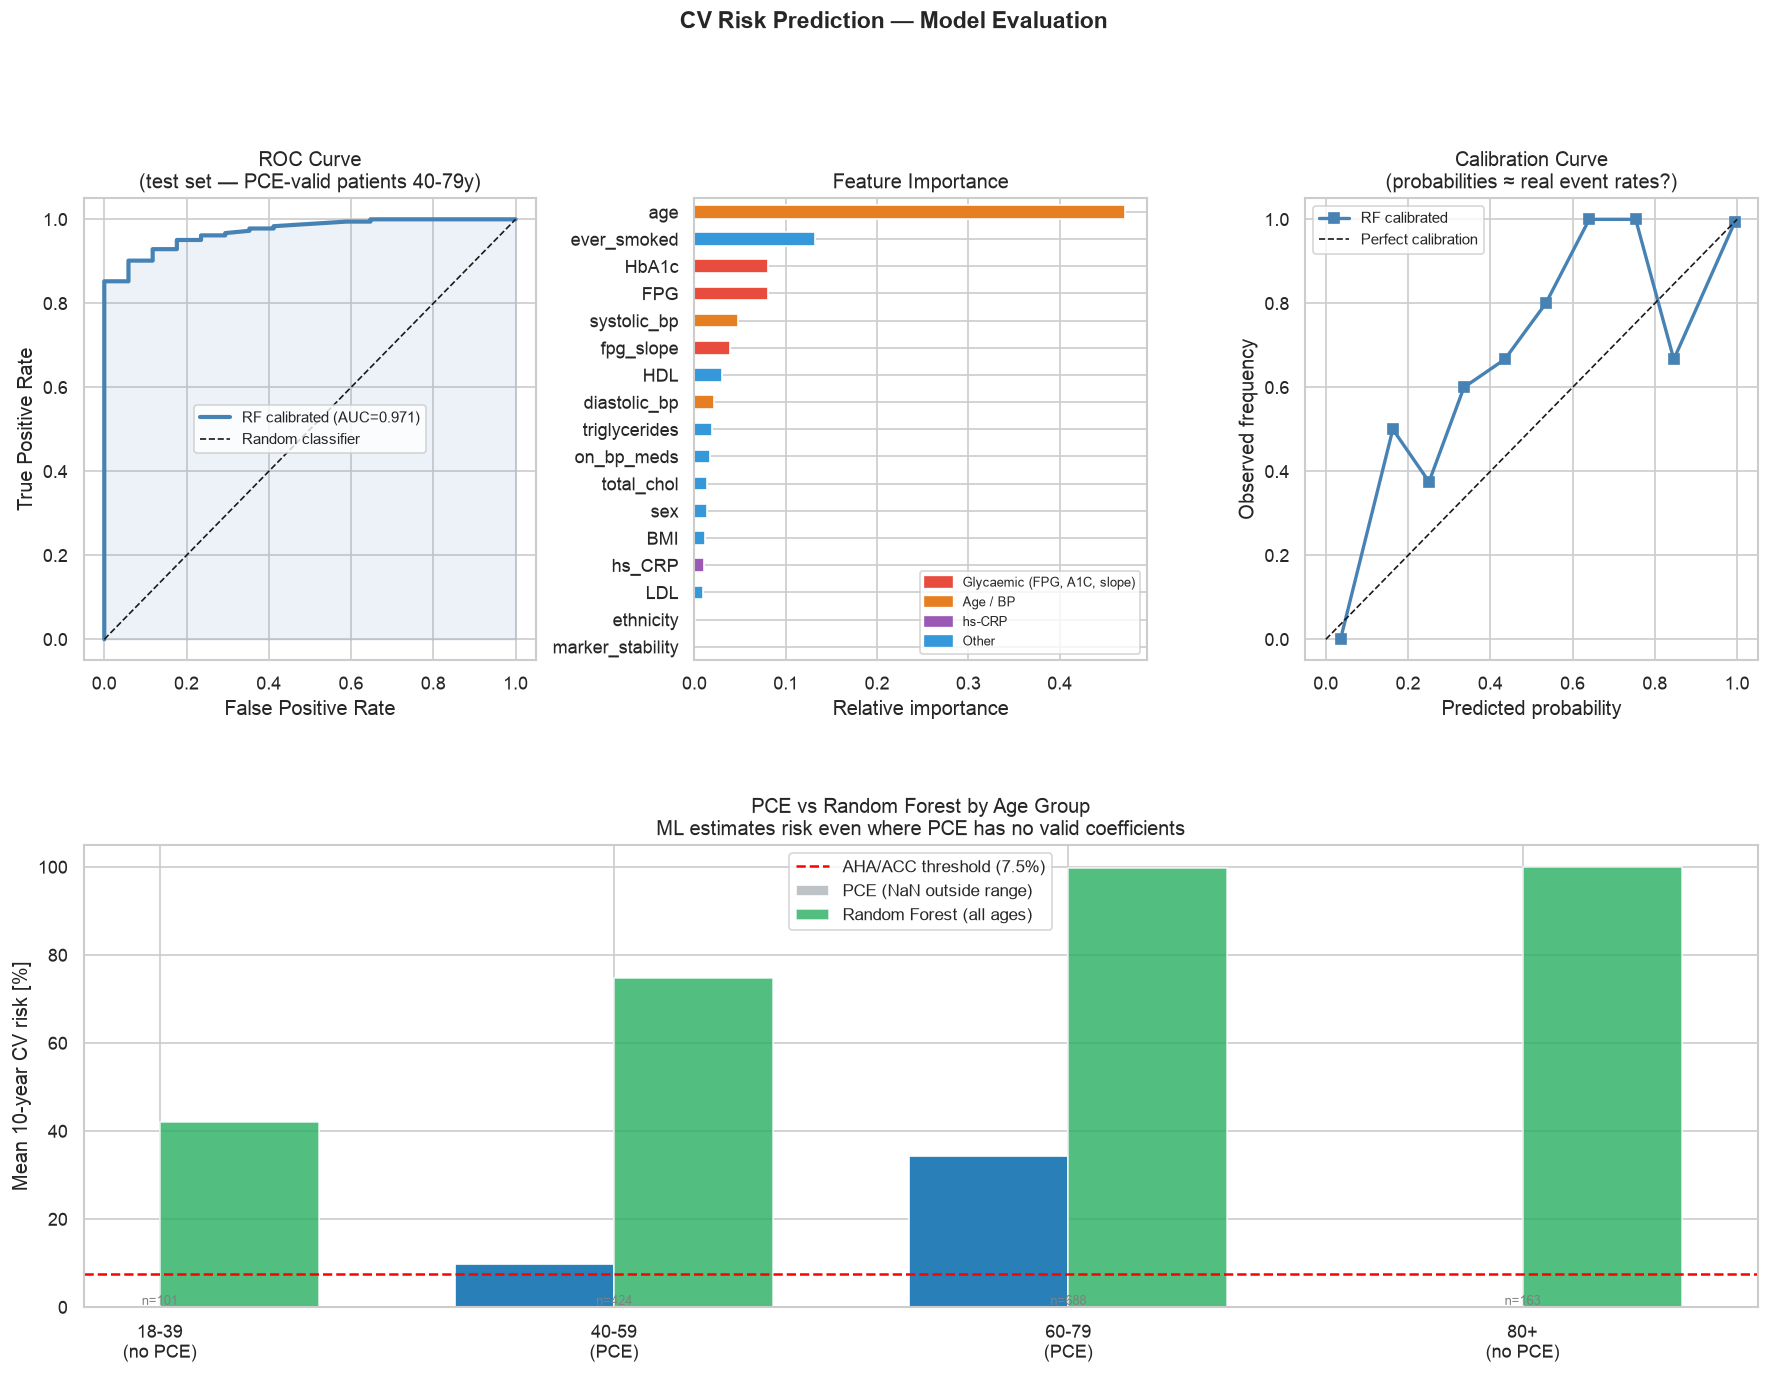

In [39]:
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :])

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax1.plot(fpr, tpr, color="steelblue", lw=2.5, label=f"RF calibrated (AUC={auc:.3f})")
ax1.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax1.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve\n(test set — PCE-valid patients 40-79y)")
ax1.legend(fontsize=9)

# 2. Feature importance
base_rf = rf.calibrated_classifiers_[0].estimator
importances = pd.Series(base_rf.feature_importances_, index=features).sort_values(ascending=True)
colors_bar = [
    "#e74c3c" if f in ["FPG", "HbA1c", "fpg_slope"] else
    "#e67e22" if f in ["age", "systolic_bp", "diastolic_bp"] else
    "#9b59b6" if f == "hs_CRP" else
    "#3498db"
    for f in importances.index
]
importances.plot(kind="barh", ax=ax2, color=colors_bar)
ax2.set_title("Feature Importance")
ax2.set_xlabel("Relative importance")
ax2.legend(handles=[
    Patch(color="#e74c3c", label="Glycaemic (FPG, A1C, slope)"),
    Patch(color="#e67e22", label="Age / BP"),
    Patch(color="#9b59b6", label="hs-CRP"),
    Patch(color="#3498db", label="Other"),
], fontsize=8, loc="lower right")

# 3. Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
ax3.plot(prob_pred, prob_true, "s-", color="steelblue", lw=2,
         label="RF calibrated")
ax3.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
ax3.set_xlabel("Predicted probability")
ax3.set_ylabel("Observed frequency")
ax3.set_title("Calibration Curve\n(probabilities ≈ real event rates?)")
ax3.legend(fontsize=9)

# 4. PCE vs RF by age group
bins_age   = [18, 39, 59, 79, 100]
labels_age = ["18-39\n(no PCE)", "40-59\n(PCE)", "60-79\n(PCE)", "80+\n(no PCE)"]
df["age_group"] = pd.cut(df["age"], bins=bins_age, labels=labels_age, right=True)

age_stats = df.groupby("age_group", observed=True).agg(
    pce_mean  =("cv_risk_10yr",  "mean"),
    ml_mean   =("rf_risk_proba", "mean"),
    count     =("rf_risk_proba", "count")
).reset_index()

x = np.arange(len(age_stats))
w = 0.35
bars1 = ax4.bar(x - w/2, age_stats["pce_mean"]*100, w,
                label="PCE (NaN outside range)",
                color=["#bdc3c7" if "no" in str(g) else "#2980b9"
                       for g in age_stats["age_group"]], edgecolor="white")
bars2 = ax4.bar(x + w/2, age_stats["ml_mean"]*100, w,
                label="Random Forest (all ages)",
                color="#27ae60", alpha=0.8, edgecolor="white")

for i, row_s in age_stats.iterrows():
    ax4.text(i, 0.5, f"n={int(row_s['count'])}", ha="center", fontsize=8, color="gray")

ax4.axhline(7.5, color="red", linestyle="--", lw=1.5, label="AHA/ACC threshold (7.5%)")
ax4.set_xticks(x)
ax4.set_xticklabels(age_stats["age_group"], fontsize=11)
ax4.set_ylabel("Mean 10-year CV risk [%]")
ax4.set_title("PCE vs Random Forest by Age Group\nML estimates risk even where PCE has no valid coefficients", fontsize=12)
ax4.legend(fontsize=10)

plt.suptitle("CV Risk Prediction — Model Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("../results/imgs/fig2-4_model_performance.png", bbox_inches="tight")
plt.show()
